## Pharmacetical Demand Analysis

## Objective

# To analyze Pharmaceutical drug demand patterns across Categories and identify Seasonal trends, Demand volatality , and Category-wise contribution using python

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('salesdaily.csv')


In [6]:
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [8]:
df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


## Data Preparation

# Converted date column into proper datetime format  

In [9]:
df['datum'] = pd.to_datetime(df['datum'])

# Removed unnecessary columns 

In [10]:
drug_cols = [col for col in df.columns if col not in ['datum','Weekday Name','Year','Month','Hour']]

# Reshaped dataset using melt (wide → long format)

In [11]:
df_long = df.melt(
    id_vars=['datum'],
    value_vars=drug_cols,
    var_name='Drug_Category',
    value_name='Sales'
)

In [13]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16848 entries, 0 to 16847
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   datum          16848 non-null  datetime64[ns]
 1   Drug_Category  16848 non-null  object        
 2   Sales          16848 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 395.0+ KB


In [14]:
df_long.describe()

,datum,Sales
count,16848,16848.000000
mean,2016-11-19 12:00:00,7.573332
min,2014-01-02 00:00:00,0.000000
25%,2015-06-12 00:00:00,1.817750
50%,2016-11-19 12:00:00,4.000000
75%,2018-04-30 00:00:00,8.000000
max,2019-10-08 00:00:00,161.000000
std,NaN,10.895998


# Mapped drug codes to main categories 


In [15]:
def map_category(cat):
    if 'M01' in cat:
        return 'Anti-inflamatory'
    elif 'N02' in cat:
        return 'Painkillers'
    elif 'N05' in cat:
        return 'Psych_Drugs'
    elif 'R03' in cat:
        return 'Respiratory'
    elif 'R06' in cat:
        return 'Allergy'
    else:
        return 'Other'
    
df_long['Main_Category'] =  df_long['Drug_Category'].apply(map_category) 

In [16]:
df_long.head()

,datum,Drug_Category,Sales,Main_Category
0,2014-01-02,M01AB,0.0,Anti-inflamatory
1,2014-01-03,M01AB,8.0,Anti-inflamatory
2,2014-01-04,M01AB,2.0,Anti-inflamatory
3,2014-01-05,M01AB,4.0,Anti-inflamatory
4,2014-01-06,M01AB,5.0,Anti-inflamatory


## Exploratory Data Analysis
# Aggregated total demand by category

In [17]:
category_demand = df_long.groupby('Main_Category')['Sales'].sum().sort_values(ascending= False)

print(category_demand)

Main_Category
Painkillers         71177.611708
Psych_Drugs         19895.695833
Anti-inflamatory    18805.555729
Respiratory         11608.822917
Allergy              6107.817500
Name: Sales, dtype: float64


## Analysing Monthly Demand trend

In [41]:
df_long['Month'] = df_long['datum'].dt.month

Monthly_demand = df_long.groupby('Month')['Sales'].sum().reset_index()

print(Monthly_demand)

    Month         Sales
0       1  13970.691083
1       2  11604.568583
2       3  11363.605000
3       4  10248.718000
4       5   9925.967667
5       6   8992.861000
6       7   8758.503333
7       8   9037.611333
8       9  11000.856667
9      10  12051.024687
10     11   9534.383333
11     12  11106.713000


##  Analyzing Category-wise Monthly Demand Patterns

In [19]:
Category_month = df_long.groupby(['Main_Category', 'Month'])['Sales'].sum().reset_index()
print(Category_month.head())

  Main_Category  Month   Sales
0       Allergy      1  299.25
1       Allergy      2  287.86
2       Allergy      3  592.34
3       Allergy      4  846.70
4       Allergy      5  930.55


## Data Visualization

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

## Comparing Total Demand Across Drug Categories

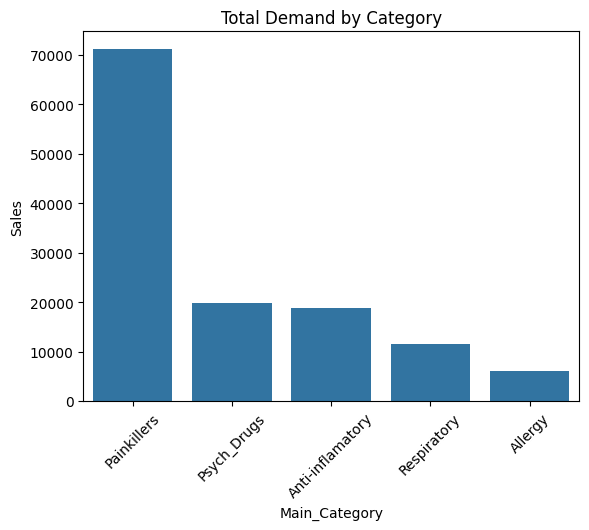

In [29]:
plt.figure()
sns.barplot(data = category_demand.reset_index(), x= 'Main_Category', y= 'Sales')

plt.xticks(rotation= 45)
plt.title('Total Demand by Category')
plt.show()

# Analyzed monthly demand trends 

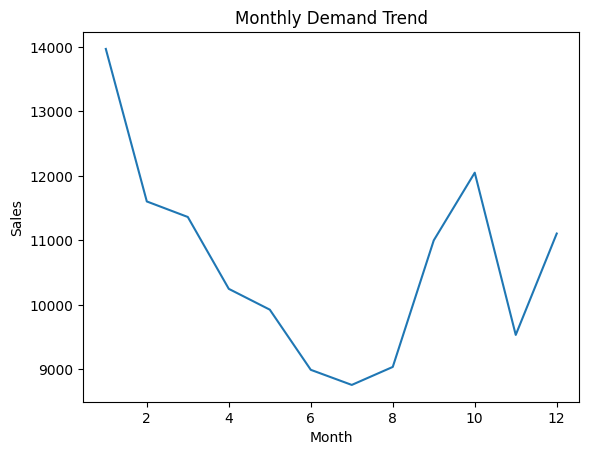

In [43]:
plt.figure()
sns.lineplot(data= Monthly_demand, x='Month',y='Sales')

plt.title("Monthly Demand Trend")
plt.show()

## Analysing seasonal demand patterns Across drug Categories

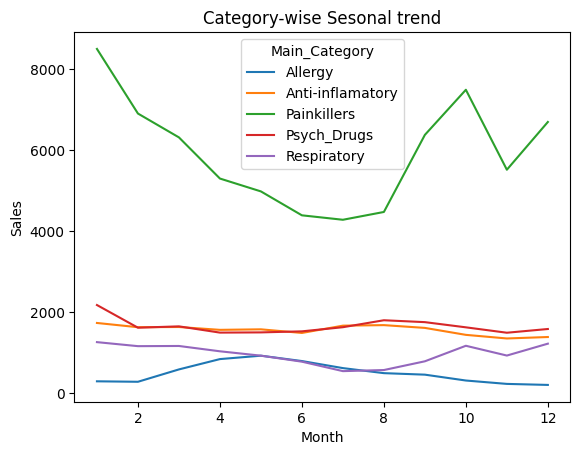

In [38]:
plt.figure()
sns.lineplot(data=Category_month, x= 'Month',y= 'Sales', hue='Main_Category')

plt.title('Category-wise Sesonal trend')
plt.show()

## Moving Average

# Applied moving average to smooth demand trends 

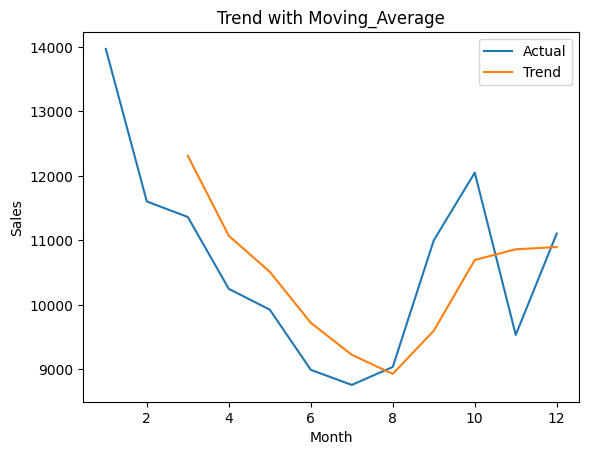

In [42]:
Monthly_demand['Moving_Avg'] = Monthly_demand['Sales'].rolling(window=3).mean()

plt.figure()
sns.lineplot(data = Monthly_demand,x='Month',y='Sales',label='Actual')
sns.lineplot(data = Monthly_demand,x='Month',y='Moving_Avg',label='Trend')

plt.title("Trend with Moving_Average")
plt.legend()
plt.show()

## Category-wise Trend

# Visualized monthly demand patterns across different drug categories to identify seasonal Sales across all the Categories

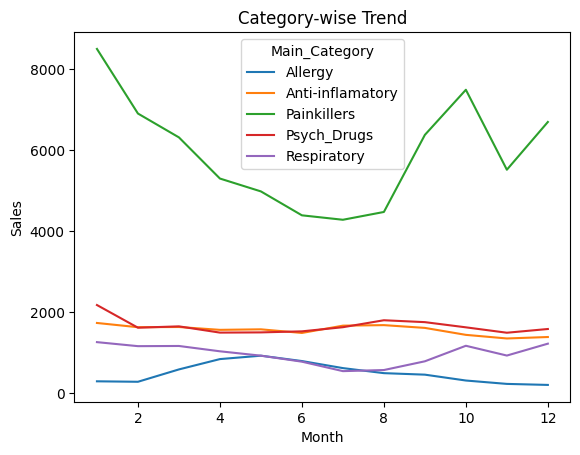

In [44]:
plt.figure
sns.lineplot(data= Category_month,x= 'Month', y= 'Sales', hue='Main_Category')

plt.title("Category-wise Trend")
plt.show()

## Normalization

# Performed normalization to compare category patterns  

In [46]:
Category_month['Normalized_Sales'] = Category_month.groupby('Main_Category')['Sales']\
    .transform(lambda x:x / x.max())

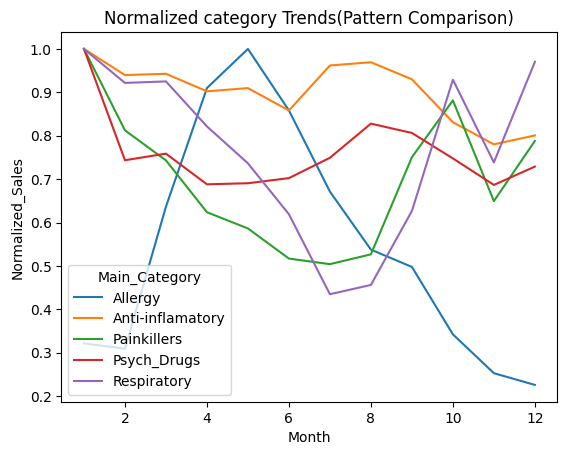

In [48]:
plt.figure()
sns.lineplot(data= Category_month, x= 'Month',y='Normalized_Sales', hue= 'Main_Category')

plt.title("Normalized category Trends(Pattern Comparison)")
plt.show()

# Even though allergy has low sales, its seasonal spike pattern is visible
# Respiratory and painkillers follow similar seasonal trend

## Volatality Analysis

# Conducted volatility analysis using standard deviation 

In [49]:
Volatality = df_long.groupby('Main_Category')['Sales'].std().sort_values(ascending=False)

print(Volatality)

Main_Category
Painkillers         17.142590
Respiratory          6.428736
Psych_Drugs          5.776350
Anti-inflamatory     2.518939
Allergy              2.415816
Name: Sales, dtype: float64


# Allergy has the stable Consumption pattern 
# Painkillers has the most unstable consumtion pattern as the sales increases in winters and decreases in summer

## Top 5 Peak days

# Analyzed daily total sales to identify the top 5 highest demand days

In [51]:
top_five = df_long.groupby('datum')['Sales'].sum().sort_values(ascending= False).head()

print(top_five)

datum
2016-12-30    198.950
2019-01-20    162.283
2016-12-31    151.239
2019-02-02    150.508
2019-01-27    145.365
Name: Sales, dtype: float64


## Key Insights

# Painkillers and respiratory drugs show strong seasonal demand with spikes during winter months (Oct–Jan), indicating correlation with seasonal illnesses.

# Psychiatric drugs exhibit stable demand throughout the year, suggesting non-seasonal consumption patterns.

# Allergy-related drugs contribute the least (~5%) and show mild spikes during monsoon season.

# Painkillers demonstrate the highest demand volatility, while anti-inflammatory and allergy categories remain relatively stable.

## Conclusion

# The analysis highlights strong seasonal behavior in certain drug categories and stable consumption in others, which can help in demand planning and inventory management.